# 02b — Auditoría de limpieza OHLCV (raw vs clean)

> **LEGACY SNAPSHOT:** conserva el análisis previo a common-core-1.0.0. No es evidencia de certificación; usar `tests/` y `COMMON_CORE_CERTIFICATION.md`.

Notebook de **diagnóstico y visualización**. No es una segunda pipeline: la fuente de verdad sigue siendo `scripts/clean_ohlcv.py` y `data/clean/ohlcv_clean.parquet`.

**Solo lectura** de `data/raw/` y `data/clean/`. No se escribe ningún panel limpio.

### Cómo ejecutarlo

Desde la raíz del repo:

```bash
uv pip install --python .venv/bin/python -r requirements.txt matplotlib ipykernel
jupyter notebook notebooks/02b_audit_cleaning.ipynb
```

Usar el kernel del `.venv` del proyecto. Detalle: `notebooks/README_02b.md`.

## 1. Setup + verificación SHA256

In [ ]:
from __future__ import annotations

import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Raíz del repo (cwd = TALLER_B5_T1/ o notebooks/)
ROOT = Path.cwd()
if not (ROOT / "data" / "raw" / "ohlcv_raw.parquet").is_file():
    if (ROOT.parent / "data" / "raw" / "ohlcv_raw.parquet").is_file():
        ROOT = ROOT.parent
    else:
        raise FileNotFoundError(
            "No se encuentra data/raw/ohlcv_raw.parquet. Ejecutar desde la raíz del repo."
        )

RAW_PATH = ROOT / "data" / "raw" / "ohlcv_raw.parquet"
CLEAN_PATH = ROOT / "data" / "clean" / "ohlcv_clean.parquet"
MANIFEST_PATH = ROOT / "data" / "clean" / "clean_manifest.json"

EXPECTED_RAW_SHA256 = (
    "6ecd4c929ecd3bdca32c646aec8210a7757b566843a90102f21bd86d2da036d6"
)
EXPECTED_CLEAN_SHA256 = (
    "fb1d9e60853743fff8cf6a2b17fb7588915d4213022c75b7311f33944a974f25"
)

OHLC_COLS = ["Open", "High", "Low", "Close"]
OHLCV_COLS = [*OHLC_COLS, "Volume"]
KEY_COLS = ["date", "ticker"]


def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


def normalize_date(series: pd.Series) -> pd.Series:
    """Misma normalización que scripts/clean_ohlcv.py (solo para auditoría)."""
    dt = pd.to_datetime(series)
    if getattr(dt.dt, "tz", None) is not None:
        dt = dt.dt.tz_convert("UTC").dt.tz_localize(None)
    return dt.dt.normalize()


def ohlc_invariant_mask(df: pd.DataFrame) -> pd.Series:
    """True = fila válida (mismas reglas que clean_ohlcv.py)."""
    return (
        (df["High"] >= df["Low"])
        & (df["High"] >= df["Open"])
        & (df["High"] >= df["Close"])
        & (df["Low"] <= df["Open"])
        & (df["Low"] <= df["Close"])
        & (df["Volume"] >= 0)
    )


raw_sha = sha256_file(RAW_PATH)
clean_sha = sha256_file(CLEAN_PATH)

sha_checks = pd.DataFrame(
    [
        {
            "artifact": "ohlcv_raw.parquet",
            "path": str(RAW_PATH.relative_to(ROOT)),
            "expected": EXPECTED_RAW_SHA256,
            "actual": raw_sha,
            "ok": raw_sha == EXPECTED_RAW_SHA256,
        },
        {
            "artifact": "ohlcv_clean.parquet",
            "path": str(CLEAN_PATH.relative_to(ROOT)),
            "expected": EXPECTED_CLEAN_SHA256,
            "actual": clean_sha,
            "ok": clean_sha == EXPECTED_CLEAN_SHA256,
        },
    ]
)
display(sha_checks)

if not sha_checks["ok"].all():
    raise RuntimeError(
        "BLOQUEADO: SHA256 no coincide con el canónico. "
        "No continuar la auditoría hasta resolver los artefactos."
    )

print("SHA256 raw/clean: OK")

,artifact,path,expected,actual,ok
0,ohlcv_raw.parquet,data/raw/ohlcv_raw.parquet,6ecd4c929ecd3bdca32c646aec8210a7757b566843a901...,6ecd4c929ecd3bdca32c646aec8210a7757b566843a901...,True
1,ohlcv_clean.parquet,data/clean/ohlcv_clean.parquet,fb1d9e60853743fff8cf6a2b17fb7588915d4213022c75...,fb1d9e60853743fff8cf6a2b17fb7588915d4213022c75...,True


SHA256 raw/clean: OK


## 2. Carga raw y clean — shapes y dtypes

In [2]:
raw = pd.read_parquet(RAW_PATH)
clean = pd.read_parquet(CLEAN_PATH)
manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))

print(f"raw shape:   {raw.shape}")
print(f"clean shape: {clean.shape}")
print()
print("=== dtypes raw ===")
display(raw.dtypes.to_frame("dtype"))
print("=== dtypes clean ===")
display(clean.dtypes.to_frame("dtype"))
print("=== head raw ===")
display(raw.head(3))
print("=== head clean ===")
display(clean.head(3))

raw shape:   (38720, 7)
clean shape: (38713, 7)

=== dtypes raw ===


,dtype
date,datetime64[ms]
ticker,str
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64


=== dtypes clean ===


,dtype
date,datetime64[ms]
ticker,str
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64


=== head raw ===


,date,ticker,Open,High,Low,Close,Volume
0,2012-01-03,ADI,26.486408,26.668021,26.086861,26.174034,3021500
1,2012-01-03,AMD,5.530000,5.590000,5.440000,5.480000,12675100
2,2012-01-03,AVGO,2.100463,2.149626,2.058425,2.062700,23032000


=== head clean ===


,date,ticker,Open,High,Low,Close,Volume
0,2012-01-03,ADI,26.486408,26.668021,26.086861,26.174034,3021500
1,2012-01-03,AMD,5.530000,5.590000,5.440000,5.480000,12675100
2,2012-01-03,AVGO,2.100463,2.149626,2.058425,2.062700,23032000


## 3. NaN por columna (raw) y confirmación en clean

Regla canónica: drop filas con NaN en `Open` / `High` / `Low` / `Close`.

In [3]:
nan_raw = (
    pd.DataFrame(
        {
            "n_nan": raw.isna().sum(),
            "pct_nan": (raw.isna().mean() * 100).round(4),
        }
    )
    .rename_axis("column")
    .reset_index()
)
display(nan_raw)

nan_ohlc_rows_raw = int(raw[OHLC_COLS].isna().any(axis=1).sum())
nan_clean = clean.isna().sum()
nan_clean_total = int(nan_clean.sum())

print(f"Filas raw con ≥1 NaN en OHLC: {nan_ohlc_rows_raw}")
print(f"NaN totales en clean (todas las columnas): {nan_clean_total}")
display(nan_clean.to_frame("n_nan_clean"))

assert nan_clean_total == 0, "FAIL inesperado: clean tiene NaN"
print("Clean: sin NaN — OK")

,column,n_nan,pct_nan
0,date,0,0.0
1,ticker,0,0.0
2,Open,0,0.0
3,High,0,0.0
4,Low,0,0.0
5,Close,0,0.0
6,Volume,0,0.0


Filas raw con ≥1 NaN en OHLC: 0
NaN totales en clean (todas las columnas): 0


,n_nan_clean
date,0
ticker,0
Open,0
High,0
Low,0
Close,0
Volume,0


Clean: sin NaN — OK


## 4. Volume == 0 en raw — destino tras la limpieza

La regla canónica exige `Volume >= 0` (no descarta ceros). Aquí comprobamos cuántos ceros hay y si siguen en clean o caen por otra regla (NaN OHLC / invariantes / cobertura).

In [4]:
# Copia normalizada solo para joins estables (no se guarda)
raw_n = raw.copy()
raw_n["date"] = normalize_date(raw_n["date"])
raw_n["ticker"] = raw_n["ticker"].astype(str)

clean_n = clean.copy()
clean_n["date"] = normalize_date(clean_n["date"])
clean_n["ticker"] = clean_n["ticker"].astype(str)

vol0 = raw_n.loc[raw_n["Volume"] == 0, [*KEY_COLS, *OHLCV_COLS]].copy()
n_vol0 = int(len(vol0))
print(f"Filas con Volume == 0 en raw: {n_vol0}")

if n_vol0 == 0:
    print("No hay ceros de volumen que auditar.")
    vol0_by_ticker = pd.DataFrame(columns=["ticker", "n_vol0"])
    vol0_fate = pd.DataFrame()
else:
    vol0_by_ticker = (
        vol0.groupby("ticker", sort=True)
        .size()
        .rename("n_vol0")
        .reset_index()
    )
    display(vol0_by_ticker)

    # Clasificar destino frente a reglas de limpieza (orden canónico)
    nan_mask = raw_n[OHLC_COLS].isna().any(axis=1)
    after_nan = raw_n.loc[~nan_mask].copy()
    valid_inv = ohlc_invariant_mask(after_nan)
    inv_fail_keys = after_nan.loc[~valid_inv, KEY_COLS]

    fate = vol0.merge(clean_n[KEY_COLS], on=KEY_COLS, how="left", indicator="in_clean")
    fate = fate.merge(
        inv_fail_keys.assign(_inv_fail=True),
        on=KEY_COLS,
        how="left",
    )
    fate["_inv_fail"] = fate["_inv_fail"].fillna(False)

    def classify_vol0(row) -> str:
        if row["in_clean"] == "both":
            return "sigue_en_clean"
        # reconstruir si tenía NaN OHLC en raw
        key = (row["date"], row["ticker"])
        raw_row = raw_n.set_index(KEY_COLS).loc[key]
        if isinstance(raw_row, pd.DataFrame):
            raw_row = raw_row.iloc[0]
        if pd.isna(raw_row[OHLC_COLS]).any():
            return "caido_por_nan_ohlc"
        if row["_inv_fail"]:
            return "caido_por_invariante"
        # si no está en clean y no falló NaN/inv → cobertura / ticker drop
        if row["ticker"] in set(manifest.get("dropped_tickers_low_coverage", [])):
            return "caido_por_cobertura_ticker"
        return "caido_por_otra_regla"

    fate["destino"] = fate.apply(classify_vol0, axis=1)
    vol0_fate = fate["destino"].value_counts().rename_axis("destino").reset_index(name="n")
    display(vol0_fate)
    display(fate[[*KEY_COLS, *OHLCV_COLS, "destino"]])
    print(
        "Nota: Volume==0 NO es causa de drop por sí sola "
        "(invariante canónica: Volume >= 0)."
    )

Filas con Volume == 0 en raw: 1


,ticker,n_vol0
0,AMD,1


,destino,n
0,sigue_en_clean,1


,date,ticker,Open,High,Low,Close,Volume,destino
0,2015-01-02,AMD,2.67,2.67,2.67,2.67,0,sigue_en_clean


Nota: Volume==0 NO es causa de drop por sí sola (invariante canónica: Volume >= 0).


## 5. Invariantes OHLC en raw

Reglas (misma máscara que `scripts/clean_ohlcv.py`):

- `High >= Low`
- `High >= Open` y `High >= Close`
- `Low <= Open` y `Low <= Close`
- `Volume >= 0`

Tras drop de NaN OHLC, las filas que fallan se eliminan. Confirmamos anti-join vs clean.

In [9]:
after_nan = raw_n.loc[~raw_n[OHLC_COLS].isna().any(axis=1)].copy()
valid = ohlc_invariant_mask(after_nan)
violations = after_nan.loc[~valid, [*KEY_COLS, *OHLCV_COLS]].copy()

# Detalle de qué check falla (útil: a menudo float edge High≈Close / Low≈Close)
violations["fail_H_ge_L"] = ~(violations["High"] >= violations["Low"])
violations["fail_H_ge_O"] = ~(violations["High"] >= violations["Open"])
violations["fail_H_ge_C"] = ~(violations["High"] >= violations["Close"])
violations["fail_L_le_O"] = ~(violations["Low"] <= violations["Open"])
violations["fail_L_le_C"] = ~(violations["Low"] <= violations["Close"])
violations["fail_V_ge_0"] = ~(violations["Volume"] >= 0)

n_violations = int(len(violations))
print(f"Violaciones de invariantes OHLC (tras NaN drop): {n_violations}")
display(violations)

# Anti-join: esas filas NO deben estar en clean
anti = violations[KEY_COLS].merge(
    clean_n[KEY_COLS],
    on=KEY_COLS,
    how="left",
    indicator=True,
)
still_in_clean = int((anti["_merge"] == "both").sum())
print(f"Violaciones que aún aparecen en clean: {still_in_clean} (esperado: 0)")
display(anti["_merge"].value_counts().rename("n").to_frame())

assert still_in_clean == 0, "FAIL: filas con invariante roto siguen en clean"
print("Anti-join: ninguna violación permanece en clean — OK")

Violaciones de invariantes OHLC (tras NaN drop): 7


,date,ticker,Open,High,Low,Close,Volume,fail_H_ge_L,fail_H_ge_O,fail_H_ge_C,fail_L_le_O,fail_L_le_C,fail_V_ge_0
2029,2012-09-25,MRVL,8.174875,8.260927,7.951141,7.951141,11043100,False,False,False,False,True,False
3380,2013-03-26,INTC,15.381342,15.735518,15.359657,15.735518,39548500,False,False,True,False,False,False
4965,2013-10-18,MCHP,15.207229,15.222339,15.052362,15.222339,2417200,False,False,True,False,False,False
7505,2014-09-19,INTC,26.800050,26.845785,26.540892,26.540892,46851900,False,False,False,False,True,False
8605,2015-02-12,INTC,26.257445,26.373356,26.087443,26.373356,20056700,False,False,True,False,False,False
10080,2015-08-25,MCHP,16.483503,16.559244,15.773935,15.773935,7894600,False,False,False,False,True,False
13914,2017-01-11,TXN,57.207034,57.636238,57.069075,57.636238,4361400,False,False,True,False,False,False


Violaciones que aún aparecen en clean: 0 (esperado: 0)


,n
_merge,
left_only,7
right_only,0
both,0


Anti-join: ninguna violación permanece en clean — OK


## 6. Antes / después — drops alineados con `clean_manifest.json`

,metric,notebook,manifest,match
0,rows_in,38720,38720,True
1,dropped_nan_ohlc,0,0,True
2,dropped_ohlc_invariant,7,7,True
3,rows_out,38713,38713,True
4,len(clean_parquet),38713,38713,True
5,calendar_n_dates,3520,3520,True


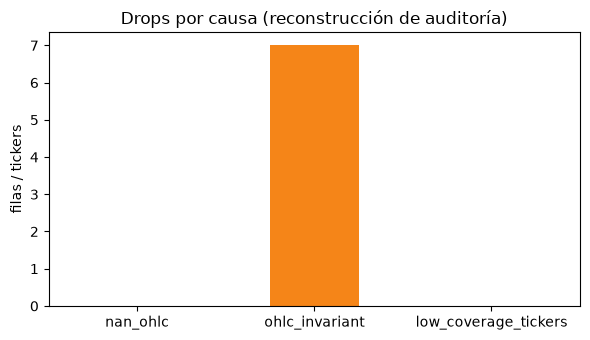

rows_in → rows_out: 38720 → 38713
Tickers dropeados por cobertura < 0.95: []


In [6]:
rows_in_nb = int(len(raw_n))
dropped_nan_nb = int(raw_n[OHLC_COLS].isna().any(axis=1).sum())
dropped_inv_nb = n_violations

# Tras NaN + invariantes (antes de filtro de cobertura), como el script
panel_after_drops = after_nan.loc[valid].copy()
calendar_n_nb = int(panel_after_drops["date"].nunique())
coverage_threshold = float(manifest["coverage_threshold"])

ticker_cov_nb: dict[str, float] = {}
dropped_tickers_nb: list[str] = []
keep_tickers_nb: list[str] = []
for t in sorted(panel_after_drops["ticker"].unique()):
    n_dates = int(panel_after_drops.loc[panel_after_drops["ticker"] == t, "date"].nunique())
    cov = n_dates / calendar_n_nb
    ticker_cov_nb[t] = round(cov, 6)
    if cov < coverage_threshold:
        dropped_tickers_nb.append(t)
    else:
        keep_tickers_nb.append(t)

rows_out_nb = int(panel_after_drops["ticker"].isin(keep_tickers_nb).sum())

comparison = pd.DataFrame(
    [
        {
            "metric": "rows_in",
            "notebook": rows_in_nb,
            "manifest": manifest["rows_in"],
        },
        {
            "metric": "dropped_nan_ohlc",
            "notebook": dropped_nan_nb,
            "manifest": manifest["dropped_nan_ohlc"],
        },
        {
            "metric": "dropped_ohlc_invariant",
            "notebook": dropped_inv_nb,
            "manifest": manifest["dropped_ohlc_invariant"],
        },
        {
            "metric": "rows_out",
            "notebook": rows_out_nb,
            "manifest": manifest["rows_out"],
        },
        {
            "metric": "len(clean_parquet)",
            "notebook": int(len(clean_n)),
            "manifest": manifest["rows_out"],
        },
        {
            "metric": "calendar_n_dates",
            "notebook": calendar_n_nb,
            "manifest": manifest["calendar_n_dates"],
        },
    ]
)
comparison["match"] = comparison["notebook"] == comparison["manifest"]
display(comparison)

drop_bar = pd.Series(
    {
        "nan_ohlc": dropped_nan_nb,
        "ohlc_invariant": dropped_inv_nb,
        "low_coverage_tickers": len(dropped_tickers_nb),
    }
)
ax = drop_bar.plot(kind="bar", color=["#4C78A8", "#F58518", "#54A24B"], figsize=(6, 3.5))
ax.set_title("Drops por causa (reconstrucción de auditoría)")
ax.set_ylabel("filas / tickers")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"rows_in → rows_out: {rows_in_nb} → {rows_out_nb}")
print(f"Tickers dropeados por cobertura < {coverage_threshold}: {dropped_tickers_nb}")

## 7. Cobertura por ticker

Definición del manifest:  
`cobertura = n_fechas_distintas(ticker) / |unión de fechas tras drops NaN + invariantes|`, umbral 0.95.

,ticker,coverage_notebook,coverage_manifest,match,below_threshold
0,ADI,1.000000,1.000000,True,False
1,AMD,1.000000,1.000000,True,False
2,AVGO,1.000000,1.000000,True,False
3,INTC,0.999148,0.999148,True,False
4,MCHP,0.999432,0.999432,True,False
5,MRVL,0.999716,0.999716,True,False
6,MU,1.000000,1.000000,True,False
7,NVDA,1.000000,1.000000,True,False
8,NXPI,1.000000,1.000000,True,False
9,QCOM,1.000000,1.000000,True,False


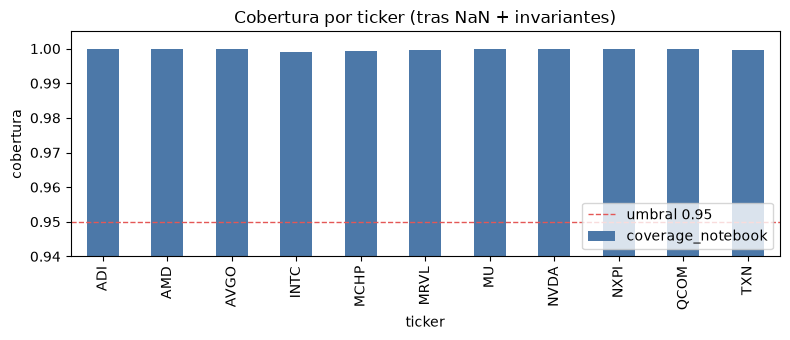

dropped_tickers_low_coverage (manifest): []
dropped_tickers_low_coverage (notebook): []


In [7]:
cov_nb = pd.Series(ticker_cov_nb, name="coverage_notebook")
cov_man = pd.Series(manifest["ticker_coverage"], name="coverage_manifest")
cov_table = (
    pd.concat([cov_nb, cov_man], axis=1)
    .rename_axis("ticker")
    .reset_index()
    .sort_values("ticker")
)
cov_table["match"] = (
    (cov_table["coverage_notebook"] - cov_table["coverage_manifest"]).abs() < 1e-9
)
cov_table["below_threshold"] = cov_table["coverage_notebook"] < coverage_threshold
display(cov_table)

ax = cov_table.set_index("ticker")["coverage_notebook"].plot(
    kind="bar", color="#4C78A8", figsize=(8, 3.5)
)
ax.axhline(coverage_threshold, color="#E45756", linestyle="--", linewidth=1, label=f"umbral {coverage_threshold}")
ax.set_ylim(0.94, 1.005)
ax.set_ylabel("cobertura")
ax.set_title("Cobertura por ticker (tras NaN + invariantes)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("dropped_tickers_low_coverage (manifest):", manifest["dropped_tickers_low_coverage"])
print("dropped_tickers_low_coverage (notebook):", dropped_tickers_nb)

## 8. PASS / FAIL vs `clean_manifest.json`

Compara conteos clave del notebook con el manifest canónico y con el parquet limpio.

In [8]:
checks: list[tuple[str, bool, str]] = []

def add(name: str, ok: bool, detail: str = "") -> None:
    checks.append((name, ok, detail))

add("sha_raw", raw_sha == EXPECTED_RAW_SHA256, raw_sha)
add("sha_clean", clean_sha == EXPECTED_CLEAN_SHA256, clean_sha)
add("rows_in", rows_in_nb == manifest["rows_in"], f"{rows_in_nb} vs {manifest['rows_in']}")
add(
    "dropped_nan_ohlc",
    dropped_nan_nb == manifest["dropped_nan_ohlc"],
    f"{dropped_nan_nb} vs {manifest['dropped_nan_ohlc']}",
)
add(
    "dropped_ohlc_invariant",
    dropped_inv_nb == manifest["dropped_ohlc_invariant"],
    f"{dropped_inv_nb} vs {manifest['dropped_ohlc_invariant']}",
)
add("rows_out", rows_out_nb == manifest["rows_out"], f"{rows_out_nb} vs {manifest['rows_out']}")
add(
    "len(clean)==rows_out",
    int(len(clean_n)) == manifest["rows_out"],
    f"{len(clean_n)} vs {manifest['rows_out']}",
)
add(
    "calendar_n_dates",
    calendar_n_nb == manifest["calendar_n_dates"],
    f"{calendar_n_nb} vs {manifest['calendar_n_dates']}",
)
tickers_out_nb = sorted(clean_n["ticker"].unique().tolist())
add(
    "tickers_out",
    tickers_out_nb == list(manifest["tickers_out"]),
    f"nb={tickers_out_nb} man={manifest['tickers_out']}",
)
add(
    "dropped_tickers_low_coverage",
    dropped_tickers_nb == list(manifest["dropped_tickers_low_coverage"]),
    f"nb={dropped_tickers_nb} man={manifest['dropped_tickers_low_coverage']}",
)
add(
    "ticker_coverage",
    ticker_cov_nb == manifest["ticker_coverage"],
    "dict coverage notebook vs manifest",
)
add("violations_absent_from_clean", still_in_clean == 0, f"still_in_clean={still_in_clean}")
add("clean_has_zero_nan", int(clean.isna().sum().sum()) == 0, "")

# Manifest declara el SHA del clean
man_clean_sha = manifest.get("checksums_sha256", {}).get(
    "data/clean/ohlcv_clean.parquet"
)
add(
    "manifest_checksum_clean",
    man_clean_sha == clean_sha,
    f"{man_clean_sha} vs {clean_sha}",
)

report = pd.DataFrame(checks, columns=["check", "ok", "detail"])
display(report)

all_ok = bool(report["ok"].all())
status = "PASS" if all_ok else "FAIL"
print("=" * 60)
print(f"RESULTADO AUDITORÍA 02b: {status}")
print("=" * 60)
if not all_ok:
    failed = report.loc[~report["ok"], ["check", "detail"]]
    print("Checks en FAIL:")
    display(failed)
    raise AssertionError("FAIL: notebook diverge del clean_manifest / panel limpio")
else:
    print(
        "Notebook cuadra con clean_manifest.json "
        f"(rows {manifest['rows_in']}→{manifest['rows_out']}, "
        f"drops nan={manifest['dropped_nan_ohlc']}, inv={manifest['dropped_ohlc_invariant']}, "
        f"tickers={len(manifest['tickers_out'])})."
    )

,check,ok,detail
0,sha_raw,True,6ecd4c929ecd3bdca32c646aec8210a7757b566843a901...
1,sha_clean,True,fb1d9e60853743fff8cf6a2b17fb7588915d4213022c75...
2,rows_in,True,38720 vs 38720
3,dropped_nan_ohlc,True,0 vs 0
4,dropped_ohlc_invariant,True,7 vs 7
5,rows_out,True,38713 vs 38713
6,len(clean)==rows_out,True,38713 vs 38713
7,calendar_n_dates,True,3520 vs 3520
8,tickers_out,True,"nb=['ADI', 'AMD', 'AVGO', 'INTC', 'MCHP', 'MRV..."
9,dropped_tickers_low_coverage,True,nb=[] man=[]


RESULTADO AUDITORÍA 02b: PASS
Notebook cuadra con clean_manifest.json (rows 38720→38713, drops nan=0, inv=7, tickers=11).
